In [1]:
import torch
torch.__version__

'2.13.0+cu130'

# Convolutional Neural Network
CNN은 비정형 데이터(여기에서 비정형은 데이터 형태는 같아도 그 속에 존재하는 값들이 표현하는 값과 특징이 달라서 비정형이라 합니다.)에서 특징을 추출해서 결과를 뽑기 쉬운 형태로 만들어 최종적으로 결과를 내주는 다층 레이어 신경망을 의미합니다.

이번에는 직접 코드를 사용하며 **FashionMNIST**라는 흑백 의류 이미지 7만장으로 구성된 데이터셋을 분석해보겠습니다.

## torch.cuda.is_available()
해당 메서드는 내부적으로 `_is_compiled()` 메서드를 사용하여 `torch._C._cuda_getDeviceCount` 속성이 있는지를 확인하게 됩니다.

이를 기반으로 CUDA의 개수가 `0` 또는 없는 경우에 True 를 반환해주게 됩니다.

In [2]:
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("device:", device)

device: cuda


# FashionMNIST 데이터 가져오기
pytorch의 torch와 다른 패키지인 torchvision 패키지에 존재하는 datasets 모듈을 이용하면 안에 정의된 Dataset 클래스를 가져올 수 있습니다.

그중에서 FashionMNIST 데이터셋 클래스는 흑백 의류 사진이 존재하는 데이터셋입니다.

FashionMNIST는 MNIST라는 VisionDataset을 상속한 클래스를 상속하여 만들어져있습니다.

구조로 보면 다음과 같습니다.
1. **torch.utils.data.Dataset**
2. **VisionDataset**
3. **MNIST**
4. **FashionMNIST**

여기에서 `train_dataset`를 datasets.FashionMNIST() 통해 만들어보게 되면 이전에 이야기했던 것처럼(다른 포스팅) 내부적으로 `__len__`, `__getitem__` 등을 제공하는 `Dataset` 객체가 만들어집니다.

## 생성자의 인자
FashionMNIST의 생성자 인자로는 다음과 같은 내용이 들어갑니다.
- root: 저장/조회 할 폴더 경로의 위치입니다. 이를 통해 디스크에 저장한다음 필요할 때 필요한 만큼씩 데이터를 불러올 수 있습니다.
- train: 테스트 데이터를 받을지 또는 훈련용 데이터를 받을지
- download: 파일이 없으면 다운받는다는 의미를 가집니다.
- transform: FashionMNIST의 생성자 구조는 기본적으로 `transform=None`이며 해당 속성은 이미지를 `__getitem__`로 아이템을 꺼낼 때 이미지에 적용할 Transform을 의미합니다.

## ToTensor()은 무엇인가
ToTensor클래스는 FashionMNIST가 이미지 객체 형태로 반환될 수 있는 것을 Tensor 형태로 변환해주기 위한 클래습니다. (callable)

이때 FashionMNIST는 흑백 이미지이기 때문에 `[1, 28, 28]` 의 형태가 나오게 됩니다.

In [3]:
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [4]:
type(train_dataset), type(test_dataset),"" , "isinstance of Dataset:",  isinstance(train_dataset, torch.utils.data.Dataset)

(torchvision.datasets.mnist.FashionMNIST,
 torchvision.datasets.mnist.FashionMNIST,
 '',
 'isinstance of Dataset:',
 True)

In [5]:
train_dataset[0][0].shape, "train:", len(train_dataset),"test:", len(test_dataset)

(torch.Size([1, 28, 28]), 'train:', 60000, 'test:', 10000)

# DataLoader 만들기

In [6]:
train_loader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=64,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=64,
    drop_last=False
)

In [7]:
images, labels = next(iter(train_loader))
print("\n --- images --- \n")
print(type(images))
print(images.shape)

print("\n --- labels --- \n")
print(type(labels))
print(labels.shape)
print(labels[0])


 --- images --- 

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])

 --- labels --- 

<class 'torch.Tensor'>
torch.Size([64])
tensor(9)


In [87]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # [1, 28, 28] -> [8, 28, 28]
        self.conv1 = nn.Conv2d(
            in_channels=1, # 이미지 데이터 (3/4차원 데이터)의 [dim-3] 의 크기를 말함
            out_channels=8, # 출력의 데이터 종류 개수 (피처맵)
            kernel_size=3, # 커널 3짜리로 8개 만든다고 볼 수 있음
            padding=1 # 상하좌우로 `0`을 채워넣기 때문에 커널에 의해 사라지는 2행/2열이 각각 상쇄됨
        )

        self.relu1 = nn.ReLU() # 활성함수 기본으로 넣기

        # [8, 28, 28] -> [8, 14, 14]
        self.pool1 = nn.MaxPool2d(
            kernel_size=2 # 2x2 짜리 커널로 특징 추출하기 (Max Pool)
        )

        # [8, 14, 14] -> [16, 14, 14]
        self.conv2 = nn.Conv2d(
            in_channels=8, # 8개의 채널을 이용하여
            out_channels=16, # 16개의 채널로 만들어주기
            kernel_size=3,
            padding=1 # 사이즈가 많이 주는 것을 막기위해 패딩을 하나 넣어주기. -> k=3, p=1 이니가 왼쪽, 위쪽 모서리가 0인 3x3
        )

        self.relu2 = nn.ReLU()

        # [16, 14, 14] -> [16, 7, 7]
        self.pool2 = nn.MaxPool2d(
            kernel_size=2 # 다시 사이즈를 1/4 로 나눠주기
        )

        # 선형변환을 통한 작업을 위한 1차원화
        # 기본 형태는 start_dim=1, end_dim=-1
        self.flatten = nn.Flatten()

        # 만들어진 flatten [n, 1] 형태를 신경망으로 64개 피처의 행렬 (데이터셋)으로 변환
        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64
        )

        # 변형된 행렬을 다시 ReLU로 음수 없애주기
        # 미분시에는 음수였던 가중치들에 대해서 이후 기울기 학습이 없어짐
        self.relu3 = nn.ReLU()

        # 앞에서 ReLU를 통해 불필요한 음수가중치를 모두 0으로 만든 데이터들을 이용하여
        # [batch, 10] 형태의 데이터셋으로 만들어주기
        self.fc2 = nn.Linear(
            64, 10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x




In [89]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [79]:
type(images), images.shape

(torch.Tensor, torch.Size([64, 1, 28, 28]))

In [17]:
len(train_loader), train_loader.batch_size, len(train_dataset)

(938, 64, 60000)

In [90]:
x = images.to(device)

print("input:", x.shape)

x = model.conv1(x)
print("conv1:",  x.shape)

x = model.relu1(x)
print("relu1:", x.shape)

x = model.pool1(x)
print("pool:", x.shape)

input: torch.Size([64, 1, 28, 28])
conv1: torch.Size([64, 8, 28, 28])
relu1: torch.Size([64, 8, 28, 28])
pool: torch.Size([64, 8, 14, 14])


In [81]:
x = model.conv2(x)
print("conv2:", x.shape)

x = model.relu2(x)
print("relu2:", x.shape)

x = model.pool2(x)
print("pool2", x.shape)

conv2: torch.Size([64, 16, 14, 14])
relu2: torch.Size([64, 16, 14, 14])
pool2 torch.Size([64, 16, 7, 7])


In [82]:
x = model.flatten(x)
print("flatten:", x.shape)

flatten: torch.Size([64, 784])


In [83]:
x = model.fc1(x)
print("fc1:", x.shape)

x = model.relu3(x)
print("relu3:", x.shape)

x = model.fc2(x)
print("fc2:", x.shape)

fc1: torch.Size([64, 64])
relu3: torch.Size([64, 64])
fc2: torch.Size([64, 10])


In [84]:
[name for name, ll in list(model.named_parameters())]

['conv1.weight',
 'conv1.bias',
 'conv2.weight',
 'conv2.bias',
 'fc1.weight',
 'fc1.bias',
 'fc2.weight',
 'fc2.bias']

In [85]:
print(type(list(model.named_parameters())[0][1]))
print(list(model.named_parameters())[0][1].grad)
print(list(model.named_parameters())[0][1].grad_fn)

<class 'torch.nn.parameter.Parameter'>
None
None


In [50]:
x.grad_fn

In [68]:
train_dataset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [74]:
images.shape, labels.shape, labels.unique()

(torch.Size([64, 1, 28, 28]),
 torch.Size([64]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [98]:
labels[0]

tensor(9)

In [93]:
x.shape

torch.Size([64, 8, 14, 14])

In [95]:
# 이미지 데이터들인 images를 CNN 모델에 돌려서 [64, 10] 형태로 변환
x = images.to(device)

logits = model(x)

print(logits.shape)

torch.Size([64, 10])


In [96]:
print(logits[0])

tensor([ 0.0457, -0.0447, -0.0290,  0.0300, -0.0251,  0.0823,  0.0336,  0.0761,
        -0.0585,  0.0619], device='cuda:0', grad_fn=<SelectBackward0>)


In [104]:
nn.Softmax()(logits[0])

tensor([0.1028, 0.0939, 0.0954, 0.1012, 0.0957, 0.1066, 0.1015, 0.1059, 0.0926,
        0.1044], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [110]:
torch.argmax(nn.Softmax()(logits[:]), dim=1).shape

torch.Size([64])

In [127]:
import pprint

# 학습 전이라 되어있는게 없음
pred = torch.argmax(nn.Softmax()(logits[:]), dim=1)
y = labels.to(device)
print("count:", len(y))
print("correct:", (pred == y).sum().item())
print("answer ratio:",(pred == y).sum().item()/len(y))
print()
pprint.pprint([(p, y, (p==y).item()) for p, y in zip(pred, y)][:6])

count: 64
correct: 8
answer ratio: 0.125

[(tensor(5, device='cuda:0'), tensor(9, device='cuda:0'), False),
 (tensor(5, device='cuda:0'), tensor(3, device='cuda:0'), False),
 (tensor(5, device='cuda:0'), tensor(5, device='cuda:0'), True),
 (tensor(5, device='cuda:0'), tensor(7, device='cuda:0'), False),
 (tensor(5, device='cuda:0'), tensor(1, device='cuda:0'), False),
 (tensor(5, device='cuda:0'), tensor(5, device='cuda:0'), True)]


In [128]:
# 역전파 한번 시켜보기
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [135]:
batch_ex = next(iter(train_loader))

batch_ex[0].shape, batch_ex[1].shape, len(train_loader),

(torch.Size([64, 1, 28, 28]), torch.Size([64]), 938)

In [134]:
epochs = 3

for epoch in range(epochs):

    model.train()

    # 한 epoch 마다 loss 모두 합쳐서 기록한다음에 한 epoch에서 얼마의 손실이 일어났는지 확인해보기
    total_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # [64, 1, 28, 28] 만큼의 grayScale 이미지 데이터셋
        images = images.to(device)
        # [64] 의 0 ~ 9 의 데이터셋
        labels = labels.to(device)

        # forward
        logits = model(images)

        # Loss
        loss = loss_fn(logits, labels)

        # 이전 gradient 제거
        # optimizer가 추적하고있는 모든 파라미터에 대한 .grad = 0 으로 바꿔주기
        optimizer.zero_grad()

        # 미분 해준다음에 속성에 넣어주기 (해당 값을 .grad = prev_grad + new_grad) 형태로 해주기 (이때 prev_grad는 0으로 초기화되어있음)
        loss.backward()

        # parameter update
        # 미분을 이용하여 학습률 적용 후 grad 파라미터에 넣어주기
        optimizer.step()

        total_loss += loss.item()

        # 총 batch 개수는 938개 이기 때문에
        if batch_idx % 200 == 0:
            print(
                f"epoch={epoch + 1}",
                f"batch={batch_idx}",
                f"loss={loss.item():.4f}"
            )
    avg_loss = total_loss / len(train_loader)

    print(
        f"[Epoch {epoch + 1}]",
        f"average loss = {avg_loss:.4f}"
    )

epoch=1 batch=0 loss=2.2975
epoch=1 batch=200 loss=0.8198
epoch=1 batch=400 loss=0.4829
epoch=1 batch=600 loss=0.4903
epoch=1 batch=800 loss=0.4879
[Epoch 1] average loss = 0.5928
epoch=2 batch=0 loss=0.4189
epoch=2 batch=200 loss=0.5710
epoch=2 batch=400 loss=0.2967
epoch=2 batch=600 loss=0.4955
epoch=2 batch=800 loss=0.4406
[Epoch 2] average loss = 0.3871
epoch=3 batch=0 loss=0.2115
epoch=3 batch=200 loss=0.3292
epoch=3 batch=400 loss=0.2620
epoch=3 batch=600 loss=0.5999
epoch=3 batch=800 loss=0.3675
[Epoch 3] average loss = 0.3413


In [136]:
print(model.conv1.weight.shape)

torch.Size([8, 1, 3, 3])


In [137]:
print(type(model.conv1.weight))

<class 'torch.nn.parameter.Parameter'>


In [139]:
print(model.conv1.weight.grad.shape)

torch.Size([8, 1, 3, 3])


In [140]:
model.eval()

correct = 0
total = 0

with torch.inference_mode():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        # 0~9 중에서 가장 높은 확률 뽑기
        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

accuracy = correct / total

print(f"accuracy: {accuracy:.4f}")


accuracy: 0.8762


In [141]:
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
model.eval()



In [143]:
test_loader.batch_size

64

In [150]:
# 64개만 뽑아서 찍어보기
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)
test_labels = test_labels.to(device)

In [145]:
# 자동으로 실행되던 Dropout를 시키지 않음
# BatchNorm은 배치 통계 되신 학습된 통계를 사용함
# gradient 계산을 함
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

accuracy: 0.8125
wrong idx: [12, 17, 21, 23, 25, 29, 40, 42, 48, 49, 50, 51]


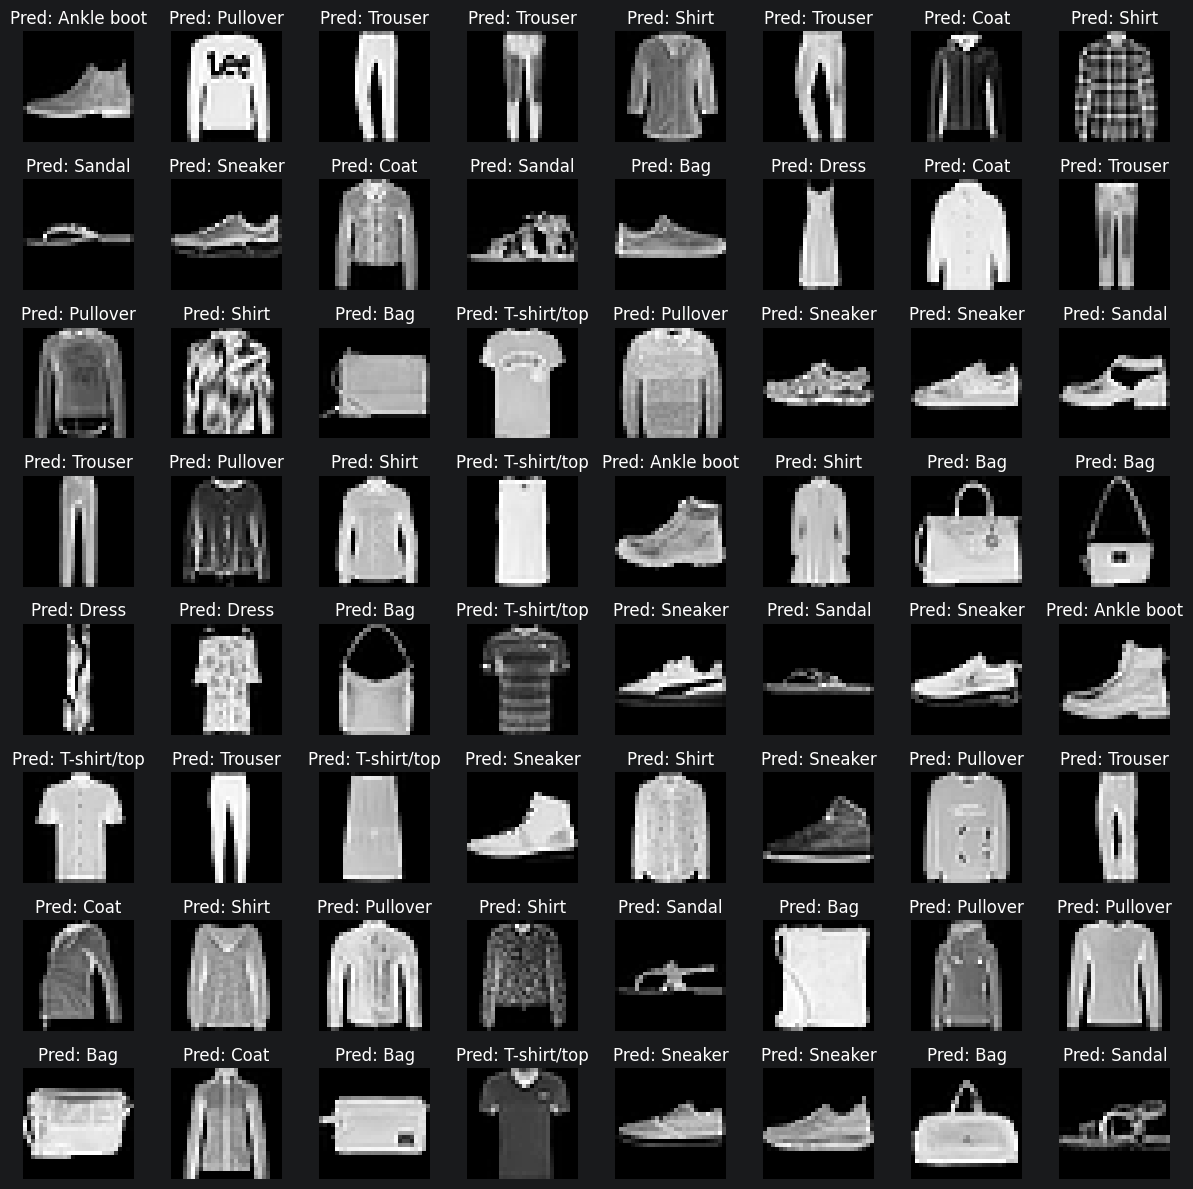

In [164]:
import matplotlib.pyplot as plt

# 미분을 자동으로 하지 않음
with torch.inference_mode():
    logits = model(test_images)
    labels_pred = torch.argmax(logits, dim=1)
    print("accuracy:", (labels_pred==test_labels).sum().item() / len(test_labels))

    print("wrong idx:", (labels_pred != test_labels).nonzero(as_tuple=False).flatten().tolist())

fig, axes = plt.subplots(8, 8, figsize=(12, 12))

idx_to_class = {
    idx: class_name
    for class_name, idx in train_dataset.class_to_idx.items()
}

for i, ax in enumerate(axes.flat):
    image = test_images[i].squeeze().cpu()
    pred = labels_pred[i].item()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Pred: {idx_to_class.get(pred, f"undefined {pred}")}")
    ax.axis("off")

plt.tight_layout()
plt.show()